# Regression track — days early or late against the promised date (dual framing)

**Problem.** For each order approved on the inference date, predict by how many calendar days it will arrive before or after its estimated delivery date (negative = early, positive = late).
- Stakeholder: customer service / fulfilment planning. They get a day-level delay estimate that complements the late/on-time flag from `model_classification_dev.ipynb`.
- Dual framing (Example 4 of the brief): the same underlying outcome drives both tasks.
  - Regression predicts the days from the promised date.
  - Classification predicts whether that number is above zero.

**What this notebook covers.** The layout follows `model_classification_dev.ipynb`:
1. Target definition, plus a censoring/horizon audit. This mirrors the classification buffer audit.
2. Training data at one run date, using the same `get_required_dates` window as classification.
3. A chronological hold-out (the test set: the newest 30 approval days of the train-test window) and day-blocked time-series CV on the training part.
4. Cross-validated defaults for two families, next to two reference baselines:
   - References: Dummy median and Olist's own promise (zero days off).
   - Linear family: Linear Regression → Ridge.
   - Tree-based family: Decision Tree → Random Forest → LightGBM.
5. Hyperparameter tuning with `RandomizedSearchCV` on the same folds.
6. Hold-out evaluation of every default and tuned model.
7. **Champion selection.** The champion is the candidate (default or tuned) with the lowest hold-out MAE, as in the classification notebook. Every later section uses it, starting with permutation importance and residuals.
8. The late flag derived from the champion's output, compared with a classifier.
9. A pooled monthly backtest on a moving window. The champion is re-selected at each monthly run date. These out-of-sample months are the results to report.

Shared code lives in `phase2/src/`. The tuned parameters and the champion are saved to `results/regression_tuning.json`. The report figures are drawn by `src/report_figures.py` and saved to `results/figures/`.

# Updates
- 20260927 - Initial regression pipeline, src/ extraction, chronological CV
- 20261003 - Restructured to follow `model_classification_dev.ipynb`:
    - Default vs tuned for every model, and a champion chosen by CV MAE
    - Hold-out lengthened from 30 to 45 days
    - Monthly backtest re-selects the champion at each run date and pools April–July 2018
    - Report figures drawn in the notebook and saved to `results/figures/`
- 20261005 - Target changed from the capped lead time to days early or late against the estimated delivery date
- 20261005 - Flow aligned with `model_classification_dev.ipynb`:
    - Same section order and names; shared `make_preprocessor`
    - Champion chosen by hold-out MAE instead of CV MAE, at the main run date and at each backtest run date
    - Hold-out shortened from 45 to 30 days, the same test period as classification
    - Resampling experiment: over- and undersampling late orders in the training data

# Environment Set-up

In [1]:
import json, os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('.') if os.path.isdir('src') else os.path.abspath('phase2'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from joblib import Parallel, delayed

from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

from src import RANDOM_STATE, LOOKBACK, PXD
from src.data import load_olist_data
from src.features import (build_feature_table, add_extra_features,
                          NUM_COLS, CAT_COLS, EXTRA_NUM_COLS, LEAKAGE_COLS)
from src.preprocessing import make_preprocessor
from src.labels import (get_required_dates, labels_as_of, regression_targets_as_of,
                        attach_regression_actuals)
from src.splits import chronological_split, day_blocked_time_series_folds, available_outcome_folds, available_training_rows
from src.evaluation import regression_metrics, classification_metrics
from src import report_figures as figs

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
np.random.seed(RANDOM_STATE)

# Constants

In [2]:
RUN_DATE = '2018-06-02'   # Same run date as model_classification_dev.ipynb
HORIZON = LOOKBACK        # Cap on the lead time inside the target, chosen in the horizon audit below
TEST_DAYS = 30            # Newest approval days held out as the test set, as in classification
N_CV_FOLDS = 5
# Random-search iterations per model; kept small for laptop run times
N_ITER = {'Ridge': 12, 'Decision Tree': 15, 'Random Forest': 6, 'LightGBM': 10}
BACKTEST_RUN_DATES = ['2018-04-02', '2018-05-02', '2018-06-02', '2018-07-02']
FIGURE_DIR = 'results/figures'  # Report figures are saved here as PNGs
EXCLUDED_STATUSES = ['canceled', 'unavailable']  # Never delivered: no delivery outcome

REG_NUM_COLS = NUM_COLS + EXTRA_NUM_COLS
REG_FEATURE_COLS = REG_NUM_COLS + CAT_COLS
assert not set(REG_FEATURE_COLS) & set(LEAKAGE_COLS), 'Outcome columns used as features'
PXD = 365  # Historical window, consistent with classification
CV_VALIDATION_DAYS = 30  # Fixed calendar length for every CV validation block


# Load data and create features

In [3]:
olist = load_olist_data()
orders = olist['orders']
final_df = add_extra_features(build_feature_table(olist), olist)
print(f'Shape: {final_df.shape}; unique orders: {final_df["order_id"].nunique():,}')

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols
Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols


Loaded reviews: 99,224 rows × 7 cols


Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


Shape: (98959, 61); unique orders: 98,959


# Target definition
**Target:** days between the customer delivery date and the estimated delivery date, in calendar days. Negative is early, positive is late:

$$y = \min(\text{lead\_days},\ H) - \text{promised\_lead\_days}$$

- `lead_days` = customer delivery date − approval date.
- `promised_lead_days` = estimated delivery date − approval date. It is shown to the customer at checkout, so it is known at approval and is also a feature.
- For an order delivered within *H* days of approval, *y* is simply delivery date − estimated delivery date.

**Why a cap on the lead time?** At run date *R*, an order approved on day *d* has been observed for only *R − d* days.
- A slow order that is still undelivered has no delivery date yet, so it is **right-censored**.
- The v2 classification labels count these orders as late (`late_undelivered`: 1,150 orders at 2018-06-02).
- Dropping them from a regression would remove exactly the worst deliveries and bias predictions downward.

With the cap, a still-undelivered order that is already *H* days old is known to have a lead time of at least *H*, so y = H − `promised_lead_days`. Every training order is at least `LOOKBACK` + 1 days old, so with *H* ≤ `LOOKBACK` the target is **fully observed for every valid training order**, using only information before the run date.

**What the cap costs.** An order capped at *H* is recorded as at most *H* − `promised_lead_days` days late. When the promise itself is longer than *H* days, a capped order is recorded as early although its outcome is not known yet. The audit counts these orders (`capped_before_promise_pct`).

**Population.** Canceled and unavailable orders never get delivered, so they have no delivery outcome; they are excluded. Orders that were shipped but never delivered are kept and capped.
- Limitation: the dataset only stores each order's final status, so the exclusion uses that snapshot. In training windows (≥ 46 days old) the cancellation would normally already be known.
- At inference time these orders are scored like any other.


## Check horizon lengths at each model training date
The table shows, for each candidate cap *H* and run date, how many training orders hit the cap and how many targets are known. This mirrors the buffer audit in the classification notebook.

In [4]:
delivered = final_df['order_delivered_customer_date'].notna()
lead_days = (final_df['order_delivered_customer_date'].dt.normalize() - final_df['order_approved_dt']).dt.days
days_from_promise = lead_days - final_df['promised_lead_days']
display(pd.DataFrame({'lead_days (delivered)': lead_days[delivered],
                      'days_from_promise (delivered)': days_from_promise[delivered]})
        .describe(percentiles=[.05, .25, .5, .75, .9, .95, .99]))

audit_rows = []
for run_date in ['2018-02-01', '2018-04-01', '2018-06-01', '2018-08-01']:
    start, end, _ = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD, verbose=False)
    window = final_df[final_df['order_approved_dt'].between(start, end)
                      & ~final_df['order_status'].isin(EXCLUDED_STATUSES)]
    for horizon in [21, 30, 45]:
        targets = regression_targets_as_of(window, run_date=run_date, horizon=horizon)
        status = targets['target_status'].value_counts(normalize=True) * 100
        capped = targets['target_status'].isin(['capped_delivered', 'capped_undelivered'])
        audit_rows.append({'run_date': run_date, 'horizon': horizon, 'orders': len(targets),
                           'known_pct': 100 * targets['target_as_of_run'].notna().mean(),
                           'capped_pct': 100 * capped.mean(),
                           'capped_before_promise_pct': 100 * (capped & targets['promised_lead_days'].gt(horizon)).mean(),
                           'unresolved_pct': status.get('unresolved', 0)})
horizon_audit = pd.DataFrame(audit_rows)
display(horizon_audit.round(2))

,lead_days (delivered),days_from_promise (delivered)
count,96190.000,96190.000
mean,11.965,-11.806
std,9.510,10.089
min,-7.000,-147.000
5%,2.000,-26.000
25%,6.000,-17.000
50%,10.000,-12.000
75%,15.000,-7.000
90%,22.000,-2.000
95%,29.000,3.000


,run_date,horizon,orders,known_pct,capped_pct,capped_before_promise_pct,unresolved_pct
0,2018-02-01,21,42427,99.980,12.540,10.710,0
1,2018-02-01,30,42427,99.980,5.910,2.180,0
2,2018-02-01,45,42427,99.980,3.040,0.140,0
3,2018-04-01,21,52671,99.980,13.650,11.980,0
4,2018-04-01,30,52671,99.980,6.170,2.410,0
5,2018-04-01,45,52671,99.980,2.920,0.120,0
6,2018-06-01,21,62581,99.980,15.740,13.090,0
7,2018-06-01,30,62581,99.980,7.220,2.380,0
8,2018-06-01,45,62581,99.980,3.110,0.110,0
9,2018-08-01,21,69405,99.980,14.940,12.360,0


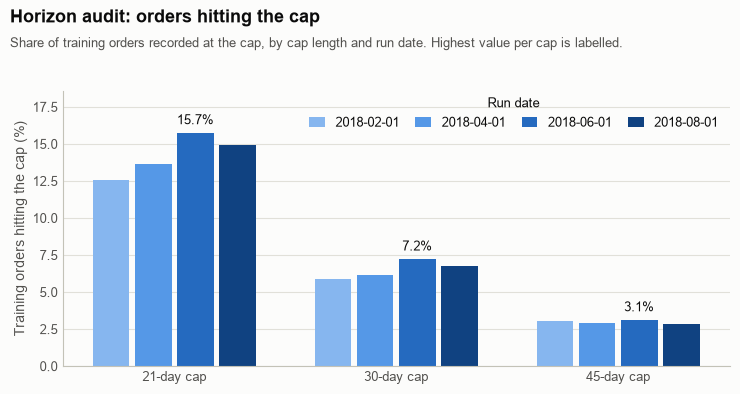

In [5]:
figs.plot_horizon_audit(horizon_audit, save_path=f'{FIGURE_DIR}/01_horizon_audit.png')

**Reading the audit.**
- At *H* = 45, about 1% of *delivered* orders exceed the cap. Counting shipped-but-never-delivered orders too, 2.8–3.1% of training orders are capped. Every valid target is known.
- At *H* = 30, 6–7% of training orders are capped, and at *H* = 21, 13–16%. That loses detail in exactly the long-delay tail the stakeholder cares about.
- Orders capped before their promised date, and so recorded as early, are 0.10–0.14% of training orders at *H* = 45. At *H* = 30 they are 2.2–2.4%, and at *H* = 21, 11–13%.
- **Decision: `HORIZON = LOOKBACK = 45`.** One buffer then serves both tasks.

# Get training data

In [6]:
train_test_start_date, train_test_end_date, inference_date = get_required_dates(
    RUN_DATE, lookback=LOOKBACK, pXd=PXD)
window = final_df[final_df['order_approved_dt'].between(train_test_start_date, train_test_end_date)]
excluded = window['order_status'].isin(EXCLUDED_STATUSES)
print(f'Excluded never-delivered orders ({", ".join(EXCLUDED_STATUSES)}): {excluded.sum():,}')

reg_audit = regression_targets_as_of(window[~excluded], run_date=RUN_DATE, horizon=HORIZON)
display(reg_audit['target_status'].value_counts().to_frame('orders'))
reg_df = reg_audit[reg_audit['target_as_of_run'].notna()].copy()
reg_df['y'] = reg_df['target_as_of_run'].astype(float)
print(f'Training/test orders with a known target: {len(reg_df):,}')

# The classification label for the same orders, for the dual-framing comparison later
reg_df['late_label'] = labels_as_of(reg_df, run_date=RUN_DATE)['label_as_of_run']

Train-test period for the inference date of 2018-06-01 with buffer of 45 days:
    2017-04-18 to 2018-04-17 (365 days)
Excluded never-delivered orders (canceled, unavailable): 753


,orders
target_status,
delivered_within_horizon,60886
capped_undelivered,1198
capped_delivered,757
invalid_or_missing_dates,11


Training/test orders with a known target: 62,841


## Train test split
- **Test:** the last `TEST_DAYS` (30) approval days of the window, the same test period as the classification notebook.
- **Train:** earlier approvals, excluding the 45 days before the hold-out and outcomes not known at hold-out start (290 days).

**Terminology.** "Hold-out" in this notebook always means this test set inside the train-test window. It is used to choose the champion. The out-of-sample months scored in the monthly backtest come later and are the results to report.

The 45-day gap mirrors deployment, where the newest training order is 45 days older than the orders being scored. The CV folds below use the same gap, and training outcomes must already be known at hold-out start.

In [7]:
train_df, test_df = chronological_split(reg_df, date_col='order_approved_dt', test_days=TEST_DAYS, gap_days=HORIZON)
train_df = available_training_rows(
    train_df, test_df['order_approved_dt'].min(), 'y',
    lambda rows, date: regression_targets_as_of(rows, date, HORIZON), 'target_as_of_run')
train_df = train_df.sort_values('order_approved_dt', kind='stable')
X_train, y_train = train_df[REG_FEATURE_COLS], train_df['y']
X_test, y_test = test_df[REG_FEATURE_COLS], test_df['y']
print(f'Train: {train_df["order_approved_dt"].min():%Y-%m-%d} to {train_df["order_approved_dt"].max():%Y-%m-%d} '
      f'({len(train_df):,} orders, mean y {y_train.mean():.2f})')
print(f'Test:  {test_df["order_approved_dt"].min():%Y-%m-%d} to {test_df["order_approved_dt"].max():%Y-%m-%d} '
      f'({len(test_df):,} orders, mean y {y_test.mean():.2f})')


Train: 2017-04-18 to 2018-02-01 (45,371 orders, mean y -11.44)
Test:  2018-03-19 to 2018-04-17 (6,847 orders, mean y -9.78)


# Preprocessor and models
Two families across the whole project, as the brief's model-family budget requires. Each starts from its simplest variant:

| Family | Baseline | More complex |
|---|---|---|
| Linear | Linear Regression | Ridge |
| Tree-based | Decision Tree | Random Forest, LightGBM |

There are also two reference baselines. They are scored everywhere but can never be the champion:
- `DummyRegressor(median)`: the typical number of days an order arrives ahead of its promise.
- **Olist promise**: predict zero, i.e. delivery exactly on the promised date (lead time capped at *H*). This is the bar that matters to the business: *does the model estimate delivery better than the date Olist already shows the customer?*

All preprocessing is fitted inside each pipeline, using the same `make_preprocessor` (`src/preprocessing.py`) as the classification pipelines:
- Median imputation, with scaling for the linear models only.
- One-hot encoding of categorical columns.

In [8]:
def make_pipeline(model, scale=False):
    return Pipeline([('preprocessor', make_preprocessor(REG_NUM_COLS, CAT_COLS, scale)), ('model', model)])

def clip_to_horizon(predicted, promised_lead_days):
    """Limit predicted days from the promise to a lead time between 0 and HORIZON days."""
    promised = np.asarray(promised_lead_days, dtype=float)
    return np.clip(predicted, -promised, HORIZON - promised)

class PromiseBaseline(DummyRegressor):
    """Predicts delivery on the promised date: zero days off (lead time capped at HORIZON)."""
    def fit(self, X, y, sample_weight=None):
        return super().fit(X, y)
    def predict(self, X):
        return clip_to_horizon(np.zeros(len(X)), X['promised_lead_days'])

reference_models = {
    'Dummy (median)': DummyRegressor(strategy='median'),
    'Olist promise': PromiseBaseline(),
}

MODEL_FAMILY = {
    'Linear Regression': 'Linear',
    'Ridge': 'Linear',
    'Decision Tree': 'Tree-based',
    'Random Forest': 'Tree-based',
    'LightGBM': 'Tree-based',
}

# Models use n_jobs=1 so parallelism happens only across CV folds/candidates,
# which avoids oversubscribing CPU cores.
default_models = {
    'Linear Regression': make_pipeline(LinearRegression(), scale=True),
    'Ridge': make_pipeline(Ridge(), scale=True),
    'Decision Tree': make_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    'Random Forest': make_pipeline(RandomForestRegressor(n_estimators=100, max_depth=10,
                                                         random_state=RANDOM_STATE, n_jobs=1)),
    'LightGBM': make_pipeline(LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1)),
}

# Small random-search spaces; widen them once the feature set is frozen.
# Linear Regression has nothing to tune.
SEARCH_SPACES = {
    'Ridge': {'model__alpha': np.logspace(-2, 3, 12)},
    'Decision Tree': {'model__max_depth': [4, 6, 8, 10, 12, None],
                      'model__min_samples_leaf': [1, 20, 50, 100, 200]},
    'Random Forest': {'model__n_estimators': [100, 200],
                      'model__max_depth': [8, 12, 16],
                      'model__min_samples_leaf': [10, 30, 60],
                      'model__max_features': [0.3, 0.5]},
    'LightGBM': {'model__n_estimators': [200, 400, 600],
                 'model__learning_rate': [0.02, 0.05, 0.1],
                 'model__num_leaves': [15, 31, 63],
                 'model__min_child_samples': [20, 50, 100],
                 'model__subsample': [0.7, 1.0], 'model__subsample_freq': [1],
                 'model__colsample_bytree': [0.6, 0.8, 1.0],
                 'model__objective': ['regression', 'regression_l1']},
}

# Time-series cross-validation & Hyperparameter tuning
Same order as the classification notebook:
1. Build the CV folds on the training part.
2. Score the default models with CV, then on the hold-out.
3. Tune with `RandomizedSearchCV` on the same folds, then score every default and tuned model on the hold-out.

## Chronological split and CV folds
- **CV:** five expanding folds, each validating on 30 calendar days.
- Leave a 45-day gap before each validation block and retain only training targets known at that block’s start.
- Keep orders from the same approval day together.

The five validation blocks are counted backwards from the end of the development-training period. For the June run, the 290-day development-training window leaves 95 initial calendar days before the first 45-day gap. As the validation date advances, each fold can use more earlier history once it is outside the 45-day gap. The date window moves with each run date; see the monthly backtest below.

In [9]:
# Fixed 30-calendar-day validation blocks, ordered chronologically.
# Each fold has a 45-day gap and outcome-availability check.
cv_folds = day_blocked_time_series_folds(
    train_df['order_approved_dt'], n_splits=N_CV_FOLDS,
    gap_days=HORIZON, validation_days=CV_VALIDATION_DAYS)
cv_folds = available_outcome_folds(
    train_df, cv_folds, y_train,
    lambda rows, date: regression_targets_as_of(rows, date, HORIZON), 'target_as_of_run')
assert len(cv_folds) == N_CV_FOLDS
print(f'CV: {len(cv_folds)} folds with a {HORIZON}-day gap and known training targets')
display(pd.DataFrame([{
            'fold': k, 'train_orders': len(tr), 'valid_orders': len(va),
            'valid_from': train_df['order_approved_dt'].iloc[va].min().date(),
            'valid_to': train_df['order_approved_dt'].iloc[va].max().date(),
            'valid_mean_y': round(y_train.iloc[va].mean(), 2),
                  } for k, (tr, va) in enumerate(cv_folds, 1)]
            ).set_index('fold')
      )

CV: 5 folds with a 45-day gap and known training targets


,train_orders,valid_orders,valid_from,valid_to,valid_mean_y
fold,,,,,
1,10697,4358,2017-09-05,2017-10-04,-11.350
2,14711,4291,2017-10-05,2017-11-03,-11.130
3,18961,7700,2017-11-04,2017-12-03,-7.950
4,23309,5202,2017-12-04,2018-01-02,-12.820
5,27919,7133,2018-01-03,2018-02-01,-12.630


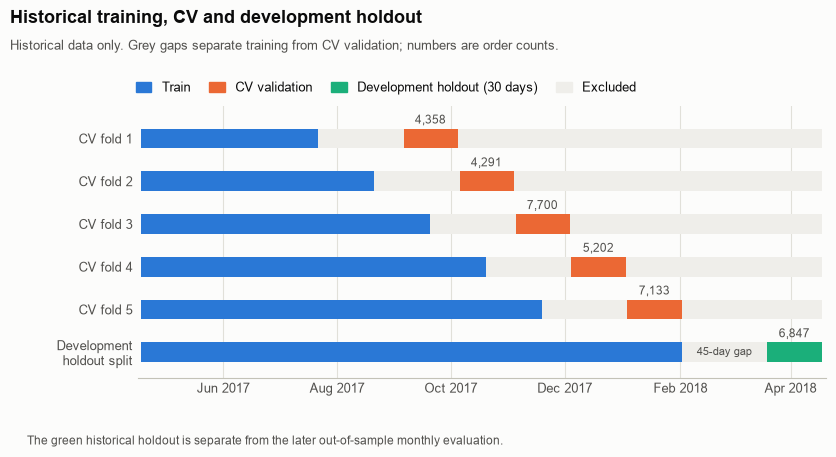

In [10]:
figs.plot_split_and_folds(train_df['order_approved_dt'], test_df['order_approved_dt'], cv_folds,
                          save_path=f'{FIGURE_DIR}/02_split_and_cv_folds.png')

## Cross-validated defaults
### Evaluation metrics from CV set
- **MAE** is the primary metric. It reads directly as "days off" in the predicted delivery date.
- RMSE and R² are reported alongside it.

In [11]:
SCORING = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

def cv_summary(model, X, y, folds, n_jobs=-1):
    """Mean and standard deviation of each CV score across the given folds."""
    scores = cross_validate(model, X, y, cv=folds, scoring=SCORING, n_jobs=n_jobs)
    row = {}
    for metric in SCORING:
        values = scores[f'test_{metric}'] * (1 if metric == 'r2' else -1)
        row[f'cv_{metric}_mean'], row[f'cv_{metric}_std'] = values.mean(), values.std()
    return row

cv_rows = []
for name, model in reference_models.items():
    cv_rows.append({'model': name, 'variant': 'reference', 'family': 'Reference',
                    **cv_summary(model, X_train, y_train, cv_folds)})
for name, model in default_models.items():
    cv_rows.append({'model': name, 'variant': 'default', 'family': MODEL_FAMILY[name],
                    **cv_summary(model, X_train, y_train, cv_folds)})
display(pd.DataFrame(cv_rows).set_index(['model', 'variant']))

,,family,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
model,variant,,,,,,,
Dummy (median),reference,Reference,6.441,0.600,9.467,0.841,-0.070,0.099
Olist promise,reference,Reference,12.810,1.163,14.255,1.107,-1.463,0.420
Linear Regression,default,Linear,6.149,1.506,9.417,2.472,-0.084,0.477
Ridge,default,Linear,6.159,1.727,9.389,2.150,-0.066,0.385
Decision Tree,default,Tree-based,8.816,1.265,12.883,1.327,-0.994,0.342
Random Forest,default,Tree-based,5.933,0.918,8.575,0.970,0.124,0.107
LightGBM,default,Tree-based,5.653,0.818,8.381,0.850,0.163,0.080


### How much does a random split flatter the scores?
This scores the same default LightGBM with random 5-fold CV on the same rows. The gap from the time-series CV is the optimism that comes from training on orders that come after some of the validation orders.

In [12]:
random_cv = cv_summary(default_models['LightGBM'], X_train, y_train,
                       KFold(5, shuffle=True, random_state=RANDOM_STATE))
time_cv = next(row for row in cv_rows if row['model'] == 'LightGBM')
display(pd.DataFrame({'random 5-fold': random_cv, 'time-series 5-fold': time_cv})
        .loc[['cv_mae_mean', 'cv_rmse_mean', 'cv_r2_mean']].astype(float))

,random 5-fold,time-series 5-fold
cv_mae_mean,5.154,5.653
cv_rmse_mean,7.712,8.381
cv_r2_mean,0.291,0.163


### Evaluation metrics from test set (held-out set)
The reference baselines and the default models are refitted on the whole training part and scored once on the hold-out. The tuned models are added after the random search.

In [13]:
holdout_metrics, test_predictions, fitted_models = {}, {}, {}

def score_holdout(key, model):
    """Fit on the training part and score the hold-out; predictions are clipped to the horizon."""
    fitted_models[key] = clone(model).fit(X_train, y_train)
    test_predictions[key] = clip_to_horizon(fitted_models[key].predict(X_test), X_test['promised_lead_days'])
    holdout_metrics[key] = regression_metrics(y_test, test_predictions[key])

for name, model in reference_models.items():
    score_holdout((name, 'reference'), model)
for name, model in default_models.items():
    score_holdout((name, 'default'), model)
display(pd.DataFrame(holdout_metrics).T.rename_axis(['model', 'variant']).sort_values('mae'))


,,mae,rmse,r2,median_ae,bias
model,variant,,,,,
LightGBM,default,5.569,8.279,0.234,3.759,-0.623
Linear Regression,default,5.585,8.341,0.222,3.787,-0.933
Ridge,default,5.602,8.305,0.229,3.856,-0.745
Random Forest,default,5.729,8.433,0.205,3.925,-0.553
Dummy (median),reference,6.733,9.864,-0.088,5.000,-3.022
Decision Tree,default,8.269,12.308,-0.694,5.000,0.323
Olist promise,reference,11.867,13.550,-1.053,11.000,9.745


## Conduct hyperparameter tuning
1. **Hyperparameter tuning** with `RandomizedSearchCV` on the time-series folds, minimising **MAE**.
2. **Hold-out evaluation** of every default and tuned model. The champion is chosen from it in the next section.
3. **Default vs tuned, compared on:**
   - the hold-out;
   - a pooled monthly backtest (April–July 2018) on a moving window.

### Random search
Each model searches a small grid (`SEARCH_SPACES` above) on the time-series folds, minimising mean MAE.
- Linear Regression has no hyperparameters, so it has a default variant only.
- The hold-out is not used for tuning.

In [14]:
tuned_models, best_params = {}, {}
for name, space in SEARCH_SPACES.items():
    search = RandomizedSearchCV(default_models[name], space, n_iter=N_ITER[name], cv=cv_folds,
                                scoring='neg_mean_absolute_error', random_state=RANDOM_STATE,
                                n_jobs=-1, refit=False)
    search.fit(X_train, y_train)
    best_params[name] = {key: (value.item() if isinstance(value, np.generic) else value)
                         for key, value in search.best_params_.items()}
    tuned_models[name] = clone(default_models[name]).set_params(**search.best_params_)
    cv_rows.append({'model': name, 'variant': 'tuned', 'family': MODEL_FAMILY[name],
                    **cv_summary(tuned_models[name], X_train, y_train, cv_folds)})
    print(f'{name}: {best_params[name]}')

cv_results = pd.DataFrame(cv_rows).set_index(['model', 'variant']).sort_index()
display(cv_results)
display((cv_results.xs('default', level='variant')['cv_mae_mean']
         - cv_results.xs('tuned', level='variant')['cv_mae_mean'])
        .dropna().rename('cv_mae_reduction_from_tuning').to_frame())

Ridge: {'model__alpha': 1000.0}


Decision Tree: {'model__min_samples_leaf': 100, 'model__max_depth': 6}


Random Forest: {'model__n_estimators': 200, 'model__min_samples_leaf': 60, 'model__max_features': 0.5, 'model__max_depth': 16}


LightGBM: {'model__subsample_freq': 1, 'model__subsample': 0.7, 'model__objective': 'regression_l1', 'model__num_leaves': 63, 'model__n_estimators': 600, 'model__min_child_samples': 50, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.6}


family  cv_mae_mean  cv_mae_std  \
model             variant                                          
Decision Tree     default    Tree-based        8.816       1.265   
                  tuned      Tree-based        5.750       0.797   
Dummy (median)    reference   Reference        6.441       0.600   
LightGBM          default    Tree-based        5.653       0.818   
                  tuned      Tree-based        5.537       0.808   
Linear Regression default        Linear        6.149       1.506   
Olist promise     reference   Reference       12.810       1.163   
Random Forest     default    Tree-based        5.933       0.918   
                  tuned      Tree-based        5.616       0.744   
Ridge             default        Linear        6.159       1.727   
                  tuned          Linear        6.059       1.541   

                             cv_rmse_mean  cv_rmse_std  cv_r2_mean  cv_r2_std  
model             variant                                                      
Decision Tree     default          12.883        1.327      -0.994      0.342  
                  tuned             8.667        0.983       0.105      0.106  
Dummy (median)    reference         9.467        0.841      -0.070      0.099  
LightGBM          default           8.381        0.850       0.163      0.080  
                  tuned             8.662        0.982       0.106      0.109  
Linear Regression default           9.417        2.472      -0.084      0.477  
Olist promise     reference        14.255        1.107      -1.463      0.420  
Random Forest     default           8.575        0.970       0.124      0.107  
                  tuned             8.467        0.879       0.146      0.086  
Ridge             default           9.389        2.150      -0.066      0.385  
                  tuned             9.309        1.935      -0.043      0.333

,cv_mae_reduction_from_tuning
model,
Decision Tree,3.066
LightGBM,0.117
Random Forest,0.317
Ridge,0.100


In [15]:
candidate_models = {**{(name, 'default'): model for name, model in default_models.items()},
                    **{(name, 'tuned'): model for name, model in tuned_models.items()}}

leaderboard = cv_results.loc[list(candidate_models),
                             ['family', 'cv_mae_mean', 'cv_mae_std', 'cv_rmse_mean', 'cv_r2_mean']]
leaderboard = leaderboard.sort_values('cv_mae_mean')
leaderboard['mae_gap_to_best'] = leaderboard['cv_mae_mean'] - leaderboard['cv_mae_mean'].iloc[0]
display(leaderboard)


,,family,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_r2_mean,mae_gap_to_best
model,variant,,,,,,
LightGBM,tuned,Tree-based,5.537,0.808,8.662,0.106,0.000
Random Forest,tuned,Tree-based,5.616,0.744,8.467,0.146,0.079
LightGBM,default,Tree-based,5.653,0.818,8.381,0.163,0.117
Decision Tree,tuned,Tree-based,5.750,0.797,8.667,0.105,0.213
Random Forest,default,Tree-based,5.933,0.918,8.575,0.124,0.397
Ridge,tuned,Linear,6.059,1.541,9.309,-0.043,0.522
Linear Regression,default,Linear,6.149,1.506,9.417,-0.084,0.612
Ridge,default,Linear,6.159,1.727,9.389,-0.066,0.622
Decision Tree,default,Tree-based,8.816,1.265,12.883,-0.994,3.279


### Hold-out evaluation (newest 30 days of the window)

In [16]:
scored_models = {**{(name, 'reference'): model for name, model in reference_models.items()},
                 **candidate_models}
for name, model in tuned_models.items():
    score_holdout((name, 'tuned'), model)
holdout_results = pd.DataFrame(holdout_metrics).T.rename_axis(['model', 'variant']).sort_values('mae')
display(holdout_results)


mae   rmse     r2  median_ae   bias
model             variant                                         
LightGBM          tuned      5.394  8.429  0.206      3.352 -1.786
                  default    5.569  8.279  0.234      3.759 -0.623
Linear Regression default    5.585  8.341  0.222      3.787 -0.933
Ridge             default    5.602  8.305  0.229      3.856 -0.745
                  tuned      5.628  8.324  0.225      3.876 -0.673
Random Forest     tuned      5.669  8.380  0.215      3.903 -0.633
                  default    5.729  8.433  0.205      3.925 -0.553
Decision Tree     tuned      5.883  8.624  0.168      4.040 -0.693
Dummy (median)    reference  6.733  9.864 -0.088      5.000 -3.022
Decision Tree     default    8.269 12.308 -0.694      5.000  0.323
Olist promise     reference 11.867 13.550 -1.053     11.000  9.745

# Use best-performing model for prediction
This section selects the champion from the hold-out results and uses it for everything that follows: interpretation on the hold-out, the derived late flag, and the monthly backtest on later, out-of-sample orders.

## Champion: lowest hold-out MAE
The **champion** is the candidate with the lowest hold-out MAE among every default and tuned model. The two reference baselines are not candidates. This is the same rule as the classification notebook, which picks its model from hold-out metrics.

- At training time the hold-out is the newest labelled data, so it is the closest available stand-in for the orders the model will score next.
- Because the hold-out is used for this choice, the champion's hold-out MAE is not an unbiased estimate. The monthly backtest below is the out-of-sample result to report.
- The choice is not fixed. `select_champion` is called again at each backtest run date on that date's own hold-out, so a different model can take over when it becomes the best one.

In [17]:
def select_champion(holdout_mae):
    """Return the (model, variant) with the lowest hold-out MAE; `holdout_mae` maps each candidate to its MAE."""
    return min(holdout_mae, key=holdout_mae.get)

champion_key = select_champion({key: holdout_results.loc[key, 'mae'] for key in candidate_models})
champion_name, champion_variant = champion_key
champion_label = f'{champion_name} ({champion_variant})'
champion_model = fitted_models[champion_key]
holdout_results.insert(0, 'champion', [key == champion_key for key in holdout_results.index])
display(holdout_results)

print(f'Champion: {champion_label}, hold-out MAE {holdout_results.loc[champion_key, "mae"]:.3f} days '
      f'(CV MAE {cv_results.loc[champion_key, "cv_mae_mean"]:.3f})')
for reference in reference_models:
    gain = holdout_results.loc[(reference, 'reference'), 'mae'] - holdout_results.loc[champion_key, 'mae']
    print(f'  Hold-out MAE improvement over {reference}: {gain:.2f} days')


champion    mae   rmse     r2  median_ae   bias
model             variant                                                   
LightGBM          tuned          True  5.394  8.429  0.206      3.352 -1.786
                  default       False  5.569  8.279  0.234      3.759 -0.623
Linear Regression default       False  5.585  8.341  0.222      3.787 -0.933
Ridge             default       False  5.602  8.305  0.229      3.856 -0.745
                  tuned         False  5.628  8.324  0.225      3.876 -0.673
Random Forest     tuned         False  5.669  8.380  0.215      3.903 -0.633
                  default       False  5.729  8.433  0.205      3.925 -0.553
Decision Tree     tuned         False  5.883  8.624  0.168      4.040 -0.693
Dummy (median)    reference     False  6.733  9.864 -0.088      5.000 -3.022
Decision Tree     default       False  8.269 12.308 -0.694      5.000  0.323
Olist promise     reference     False 11.867 13.550 -1.053     11.000  9.745

Champion: LightGBM (tuned), hold-out MAE 5.394 days (CV MAE 5.537)
  Hold-out MAE improvement over Dummy (median): 1.34 days
  Hold-out MAE improvement over Olist promise: 6.47 days


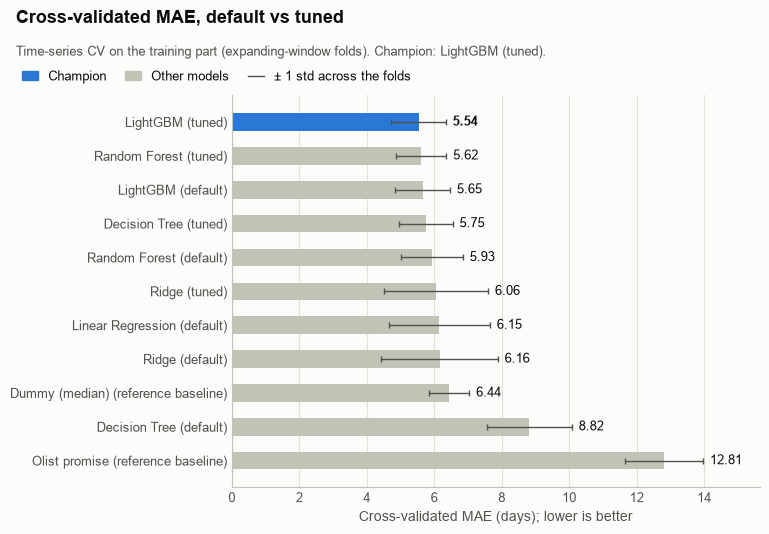

In [18]:
figs.plot_cv_mae(cv_results, champion_key, save_path=f'{FIGURE_DIR}/03_cv_mae_default_vs_tuned.png')

## Interpretation
The champion is fitted on the training part and explained on the hold-out.

### Permutation importance (test set, raw features)

In [19]:
perm = permutation_importance(champion_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE,
                              scoring='neg_mean_absolute_error', n_jobs=-1)
importance = (pd.DataFrame({'feature': REG_FEATURE_COLS,
                            'mae_increase_days': perm.importances_mean,
                            'std': perm.importances_std})
              .sort_values('mae_increase_days', ascending=False).head(20).reset_index(drop=True))
display(importance)

,feature,mae_increase_days,std
0,promised_lead_days,2.581,0.018
1,customer_state,0.255,0.012
2,seller_dist_km_min,0.171,0.008
3,route_type,0.052,0.004
4,seller_dist_km_median,0.044,0.003
5,seller_dist_km_max,0.026,0.003
6,order_product_weight_g_sum,0.023,0.004
7,order_approved_day_of_week,0.023,0.004
8,order_product_volume_cm3_sum,0.022,0.005
9,order_frieght_value_sum,0.019,0.003


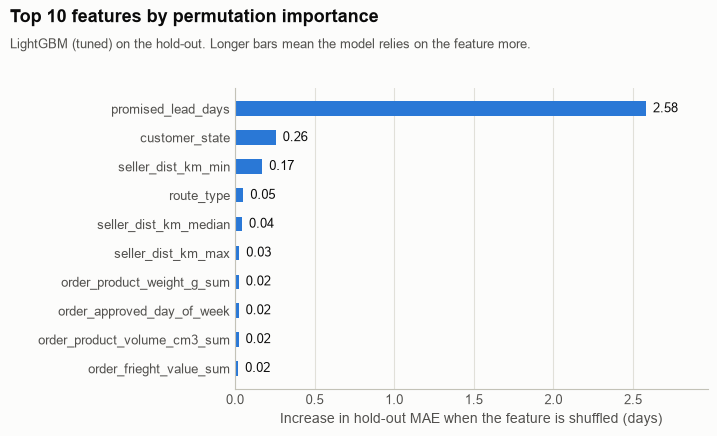

In [20]:
figs.plot_feature_importance(importance.head(10), champion_label,
                             save_path=f'{FIGURE_DIR}/06_feature_importance.png')

### Residuals by segment

,orders,actual_mean,predicted_mean,bias,mae
route_type,,,,,
1. All interstate,4109,-10.104,-12.317,-2.212,6.630
2. All same-state,2715,-9.207,-10.369,-1.161,3.552
3. Mixed,23,-18.957,-18.298,0.659,2.210


,orders,actual_mean,predicted_mean,bias,mae
customer_state,,,,,
SP,3071,-9.821,-10.858,-1.037,3.718
RJ,798,-12.006,-13.917,-1.911,8.579
MG,782,-10.514,-12.685,-2.171,5.118
RS,382,-12.047,-12.809,-0.762,6.042
PR,363,-12.102,-12.287,-0.185,4.408
SC,225,-10.884,-10.602,0.282,5.023
BA,219,-4.402,-10.102,-5.701,8.071
ES,144,-4.583,-9.959,-5.376,7.378
DF,139,-10.367,-10.459,-0.093,4.541


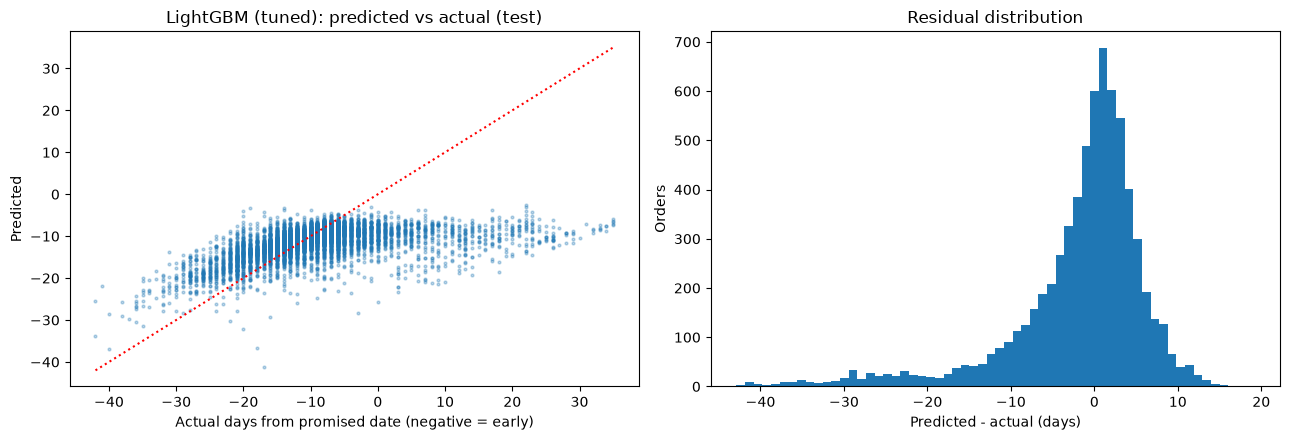

In [21]:
residuals = test_df[['customer_state', 'route_type']].copy()
residuals['actual'] = y_test.to_numpy()
residuals['predicted'] = test_predictions[champion_key]
residuals['error'] = residuals['predicted'] - residuals['actual']
for segment in ['route_type', 'customer_state']:
    table = residuals.groupby(segment).agg(orders=('error', 'size'), actual_mean=('actual', 'mean'),
                                           predicted_mean=('predicted', 'mean'), bias=('error', 'mean'),
                                           mae=('error', lambda e: e.abs().mean()))
    display(table.sort_values('orders', ascending=False).head(12))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(residuals['actual'], residuals['predicted'], s=4, alpha=0.3)
limits = [residuals[['actual', 'predicted']].min().min(), residuals[['actual', 'predicted']].max().max()]
axes[0].plot(limits, limits, color='red', linestyle=':')
axes[0].set(xlabel='Actual days from promised date (negative = early)', ylabel='Predicted',
            title=f'{champion_label}: predicted vs actual (test)')
axes[1].hist(residuals['error'], bins=60)
axes[1].set(xlabel='Predicted - actual (days)', ylabel='Orders', title='Residual distribution')
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/08_predicted_vs_actual.png', dpi=200)
plt.show()

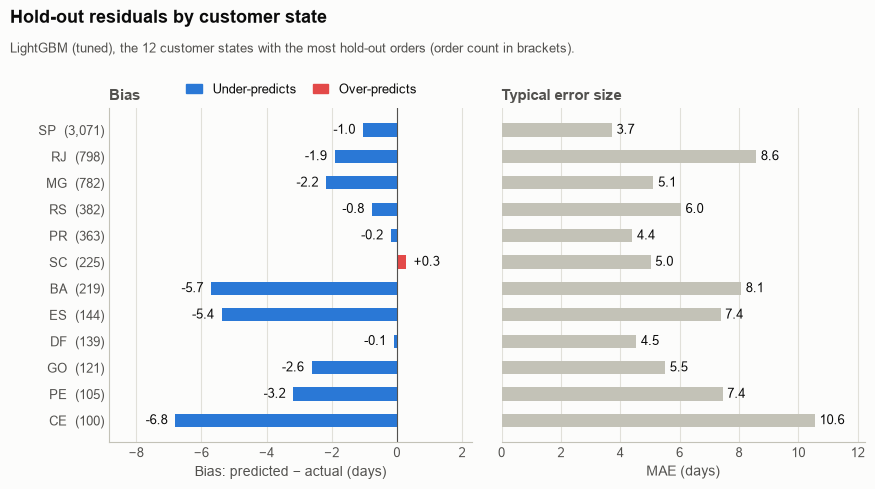

In [22]:
figs.plot_residuals_by_state(residuals, champion_label,
                             save_path=f'{FIGURE_DIR}/07_residuals_by_state.png')

## Dual framing: a late flag derived from the regression output
An order is flagged late when the champion's **predicted days from the promised date are above zero**. This is the same outcome as the classification label.

The table compares this flag on the same chronological test set with:
- a LightGBM classifier trained on the same features and split, at a 0.5 threshold;
- a Logistic Regression classifier.

It also checks what the new features add to the classifier. PR-AUC is compared with the base feature set (`NUM_COLS + CAT_COLS`) and with the extended one.

In [23]:
# A few orders have a regression target but no late label yet (promised date still ahead)
test_known, train_known = test_df['late_label'].notna(), train_df['late_label'].notna()
print(f'Orders without a known late label (excluded here): train {(~train_known).sum()}, test {(~test_known).sum()}')
cls_train, cls_test = train_df[train_known], test_df[test_known]
test_late = cls_test['late_label'].astype(int)
train_late = cls_train['late_label'].astype(int)
margin = test_predictions[champion_key][test_known.to_numpy()]  # Predicted days after the promise
dual_rows = {'Regression-derived flag': classification_metrics(test_late, (margin > 0).astype(int), margin)}

def fit_classifier(model, num_cols, scale):
    pipeline = Pipeline([('preprocessor', make_preprocessor(num_cols, CAT_COLS, scale)), ('model', model)])
    pipeline.fit(cls_train[num_cols + CAT_COLS], train_late)
    prob = pipeline.predict_proba(cls_test[num_cols + CAT_COLS])[:, 1]
    return classification_metrics(test_late, (prob >= 0.5).astype(int), prob)

ratio = (train_late == 0).sum() / (train_late == 1).sum()
for label, cols in [('v2 features', NUM_COLS), ('v2 + extra features', REG_NUM_COLS)]:
    dual_rows[f'LightGBM classifier ({label})'] = fit_classifier(
        LGBMClassifier(scale_pos_weight=ratio, random_state=RANDOM_STATE, verbosity=-1), cols, scale=False)
    dual_rows[f'LogisticRegression ({label})'] = fit_classifier(
        LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE), cols, scale=True)
print(f'Test late rate: {test_late.mean():.2%}')
display(pd.DataFrame(dual_rows).T)

Orders without a known late label (excluded here): train 0, test 1


Test late rate: 10.06%


,roc_auc,pr_auc,accuracy,precision,recall,f1_score
Regression-derived flag,0.640,0.169,0.899,0.000,0.000,0.000
LightGBM classifier (v2 features),0.600,0.157,0.676,0.139,0.430,0.210
LogisticRegression (v2 features),0.683,0.193,0.768,0.207,0.463,0.286
LightGBM classifier (v2 + extra features),0.684,0.211,0.747,0.205,0.527,0.295
LogisticRegression (v2 + extra features),0.713,0.224,0.731,0.208,0.595,0.308


## Pooled monthly backtest on a moving window, April–July 2018
This follows the classification notebook's inference flow. The training window moves forward one month at a time:
1. On the 2nd of each month, take that run date's own 365-day window. It ends 45 days before the inference date, so every target in it is known.
2. **Re-select the champion as of that run date.** The window gets the same chronological split as above (30-day hold-out after a 45-day gap). Every candidate is fitted on the training part, and the one with the lowest MAE on that window's hold-out becomes that month's champion.
3. Refit every candidate on the whole window and score every order approved that month. The `Champion` row uses that month's champion's predictions.
4. Evaluate each daily cohort once its target is known, at approval day + `HORIZON`.

Hyperparameters are chosen once in the June development run and reused for all backtest months. Their CV validation approvals end on 1 February 2018, but outcomes are constructed at the June run date; the April and May runs should therefore be interpreted as retrospective comparisons. The delivery data ends in mid-October 2018, so July 2018 is the last month that can be fully evaluated.

In [24]:
def backtest_month(run_date):
    start, end, _ = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD, verbose=False)
    history = final_df[final_df['order_approved_dt'].between(start, end)
                       & ~final_df['order_status'].isin(EXCLUDED_STATUSES)]
    targets = regression_targets_as_of(history, run_date=run_date, horizon=HORIZON)
    targets = targets[targets['target_as_of_run'].notna()]
    targets = targets.assign(y=targets['target_as_of_run'].astype(float))

    # Champion as of this run date: lowest MAE on this window's own hold-out
    month_train, month_holdout = chronological_split(targets, date_col='order_approved_dt', test_days=TEST_DAYS, gap_days=HORIZON)
    month_train = available_training_rows(
        month_train, month_holdout['order_approved_dt'].min(), 'y',
        lambda rows, date: regression_targets_as_of(rows, date, HORIZON), 'target_as_of_run')
    month_holdout_mae = {}
    for key, model in candidate_models.items():
        fitted = clone(model).fit(month_train[REG_FEATURE_COLS], month_train['y'])
        predicted = clip_to_horizon(fitted.predict(month_holdout[REG_FEATURE_COLS]),
                                    month_holdout['promised_lead_days'])
        month_holdout_mae[key] = regression_metrics(month_holdout['y'], predicted)['mae']
    month_champion = select_champion(month_holdout_mae)

    month = pd.Period(run_date, 'M')
    cohort = final_df[final_df['order_approved_dt'].dt.to_period('M').eq(month)]
    frames = []
    for (name, variant), model in scored_models.items():
        fitted = clone(model).fit(targets[REG_FEATURE_COLS], targets['y'])
        frame = cohort[['order_id', 'order_approved_dt']].copy()
        frame['predicted'] = clip_to_horizon(fitted.predict(cohort[REG_FEATURE_COLS]), cohort['promised_lead_days'])
        frame['model'], frame['variant'], frame['month'] = name, variant, str(month)
        frames.append(frame)
        if (name, variant) == month_champion:
            frames.append(frame.assign(model='Champion', variant='re-selected monthly'))
    champion_row = {'month': str(month), 'train_orders': len(targets),
                    'champion': f'{month_champion[0]} ({month_champion[1]})',
                    'champion_holdout_mae': month_holdout_mae[month_champion]}
    return pd.concat(frames, ignore_index=True), champion_row

backtest_runs = Parallel(n_jobs=-1)(delayed(backtest_month)(d) for d in BACKTEST_RUN_DATES)
backtest = pd.concat([predictions for predictions, _ in backtest_runs], ignore_index=True)
backtest_actuals = attach_regression_actuals(backtest[['order_id']].drop_duplicates(), orders,
                                             horizon=HORIZON)
backtest = backtest.merge(backtest_actuals[['order_id', 'actual_target', 'target_status']], on='order_id')
known_orders = backtest_actuals['actual_target'].notna()
print(f'April-July backtest orders: known targets at approval day + {HORIZON} days: '
      f'{known_orders.sum():,}/{len(backtest_actuals):,} ({known_orders.mean():.2%})')

April-July backtest orders: known targets at approval day + 45 days: 26,166/26,184 (99.93%)


In [25]:
def backtest_metrics(group):
    known = group[group['actual_target'].notna()]
    return pd.Series(regression_metrics(known['actual_target'].astype(float), known['predicted']))

backtest_monthly = backtest.groupby(['month', 'model', 'variant']).apply(backtest_metrics).reset_index()

# Which candidate actually scored best each month, to check the champion picks
candidates_monthly = backtest_monthly[backtest_monthly['variant'].isin(['default', 'tuned'])]
hindsight = candidates_monthly.loc[candidates_monthly.groupby('month')['mae'].idxmin()].set_index('month')
champions = pd.DataFrame([row for _, row in backtest_runs]).set_index('month')
champions['champion_backtest_mae'] = (backtest_monthly[backtest_monthly['model'].eq('Champion')]
                                      .set_index('month')['mae'])
champions['best_in_hindsight'] = hindsight['model'] + ' (' + hindsight['variant'] + ')'
champions['best_in_hindsight_mae'] = hindsight['mae']
print('Champion at each run date:')
display(champions)

print('MAE by month:')
display(backtest_monthly.pivot_table(index=['model', 'variant'], columns='month', values='mae'))
print('Equal-weight monthly mean and std:')
display(backtest_monthly.groupby(['model', 'variant'])[['mae', 'rmse', 'r2', 'bias']]
        .agg(['mean', 'std']).sort_values(('mae', 'mean')))
print('Pooled over all four months:')
backtest_pooled = backtest.groupby(['model', 'variant']).apply(backtest_metrics).sort_values('mae')
display(backtest_pooled)

Champion at each run date:


,train_orders,champion,champion_holdout_mae,champion_backtest_mae,best_in_hindsight,best_in_hindsight_mae
month,,,,,,
2018-04,52919,Ridge (tuned),5.695,5.620,LightGBM (tuned),5.168
2018-05,58175,LightGBM (default),7.495,7.187,LightGBM (tuned),5.681
2018-06,62841,LightGBM (tuned),5.377,4.846,LightGBM (tuned),4.846
2018-07,67399,LightGBM (tuned),5.435,4.417,LightGBM (tuned),4.417


MAE by month:


month                                  2018-04  2018-05  2018-06  2018-07
model             variant                                                
Champion          re-selected monthly    5.620    7.187    4.846    4.417
Decision Tree     default                8.100   10.167    7.686    7.542
                  tuned                  5.915    7.065    7.547    5.231
Dummy (median)    reference              6.018    7.210    9.248    5.720
LightGBM          default                5.960    7.187    6.181    5.221
                  tuned                  5.168    5.681    4.846    4.417
Linear Regression default                5.484    6.312    6.549    5.666
Olist promise     reference             13.820   13.020   19.307   12.390
Random Forest     default                5.807    7.485    7.027    5.214
                  tuned                  5.814    6.917    6.350    5.069
Ridge             default                5.538    6.317    6.544    5.656
                  tuned                  5.620    6.322    6.689    5.613

Equal-weight monthly mean and std:


mae         rmse           r2        \
                                        mean   std   mean   std   mean   std   
model             variant                                                      
LightGBM          tuned                5.028 0.533  7.570 0.497  0.379 0.097   
Champion          re-selected monthly  5.517 1.220  7.903 1.003  0.326 0.122   
Linear Regression default              6.002 0.509  8.075 0.156  0.295 0.066   
Ridge             default              6.014 0.492  8.075 0.149  0.295 0.066   
Random Forest     tuned                6.037 0.787  8.211 0.528  0.275 0.041   
Ridge             tuned                6.061 0.535  8.111 0.156  0.289 0.067   
LightGBM          default              6.137 0.812  8.267 0.684  0.265 0.062   
Random Forest     default              6.383 1.054  8.554 0.754  0.215 0.039   
Decision Tree     tuned                6.439 1.057  8.716 0.589  0.183 0.054   
Dummy (median)    reference            7.049 1.601 10.025 1.369 -0.089 0.267   
Decision Tree     default              8.374 1.218 12.449 1.185 -0.668 0.193   
Olist promise     reference           14.634 3.170 16.390 3.046 -1.968 1.143   

                                        bias        
                                        mean   std  
model             variant                           
LightGBM          tuned                1.004 1.055  
Champion          re-selected monthly  2.016 1.650  
Linear Regression default              2.752 1.501  
Ridge             default              2.784 1.454  
Random Forest     tuned                2.840 1.441  
Ridge             tuned                2.847 1.496  
LightGBM          default              3.135 1.243  
Random Forest     default              3.244 1.742  
Decision Tree     tuned                3.012 2.027  
Dummy (median)    reference            1.397 3.746  
Decision Tree     default              3.840 1.213  
Olist promise     reference           13.271 3.651

Pooled over all four months:


mae   rmse     r2  median_ae   bias
model             variant                                                   
LightGBM          tuned                5.054  7.605  0.443      3.681  0.991
Champion          re-selected monthly  5.578  7.999  0.383      4.186  2.072
Linear Regression default              6.001  8.078  0.371      4.875  2.705
Ridge             default              6.013  8.078  0.371      4.891  2.740
                  tuned                6.059  8.114  0.366      4.965  2.803
Random Forest     tuned                6.063  8.247  0.345      4.898  2.840
LightGBM          default              6.170  8.321  0.333      4.971  3.145
Random Forest     default              6.408  8.607  0.286      5.135  3.237
Decision Tree     tuned                6.449  8.743  0.263      5.060  2.987
Dummy (median)    reference            7.031 10.080  0.021      5.000  1.296
Decision Tree     default              8.429 12.543 -0.516      5.000  3.857
Olist promise     reference           14.560 16.525 -1.631     14.000 13.180

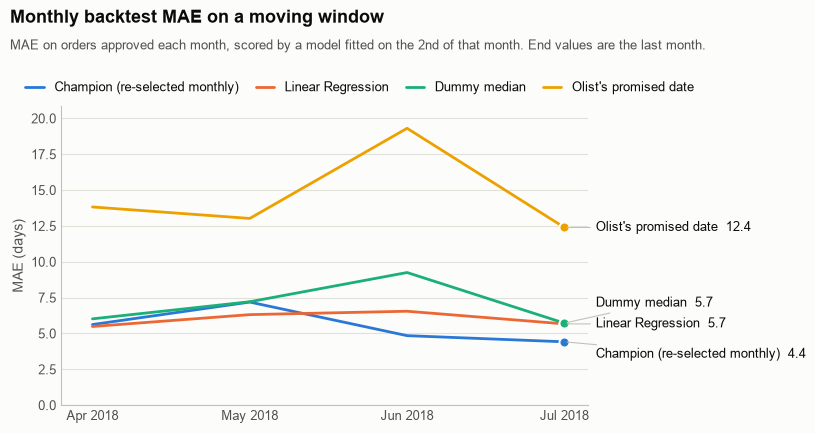

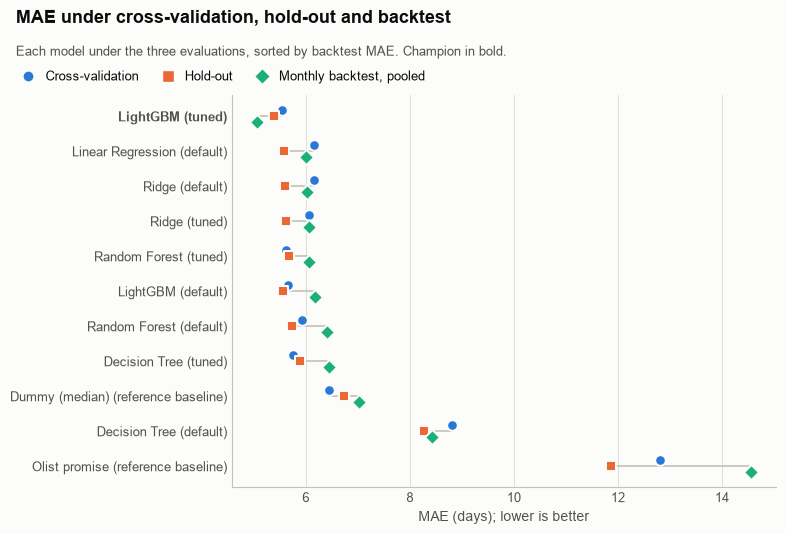

In [26]:
figs.plot_backtest_by_month(backtest_monthly, [
    ('Champion', 're-selected monthly', 'Champion (re-selected monthly)'),
    ('Linear Regression', 'default', 'Linear Regression'),
    ('Dummy (median)', 'reference', 'Dummy median'),
    ('Olist promise', 'reference', "Olist's promised date"),
], save_path=f'{FIGURE_DIR}/05_monthly_backtest_mae.png')
figs.plot_mae_across_evaluations(cv_results, holdout_results, backtest_pooled, champion_key,
                                 save_path=f'{FIGURE_DIR}/04_mae_cv_holdout_backtest.png')

## Resampling experiment: over- and undersampling late orders
A regression target has no classes, so resampling is done on the side of the target that matters to the business: **late orders** (y > 0) against early and on-time orders (y ≤ 0).
- **Oversampling** repeats late training orders at random until the two groups are the same size.
- **Undersampling** drops early and on-time training orders at random until the two groups are the same size.
- Only training rows are resampled. The hold-out and the backtest months are scored as they are.

The champion's pipeline is refitted on each version of the training data and compared on:
- the hold-out (fitted on the training part);
- the April–July backtest (fitted on each run date's whole window, as in the backtest above).

MAE is shown overall and separately for late and other orders. The late flag is "predicted days above zero".

In [27]:
def resample_training(rows, method, random_state=RANDOM_STATE):
    """Balance late orders (y > 0) against the rest 1:1; `method` is 'none', 'oversample' or 'undersample'."""
    late, rest = rows[rows['y'] > 0], rows[rows['y'] <= 0]
    if method == 'oversample':
        late = late.sample(len(rest), replace=True, random_state=random_state)
    elif method == 'undersample':
        rest = rest.sample(len(late), replace=False, random_state=random_state)
    elif method != 'none':
        raise ValueError(f'Unknown resampling method: {method}')
    return pd.concat([late, rest]).sort_values('order_approved_dt', kind='stable')

def resampling_metrics(actual, predicted):
    """Regression errors overall and by actual lateness, plus the derived late flag."""
    actual, predicted = np.asarray(actual, dtype=float), np.asarray(predicted, dtype=float)
    late, error = actual > 0, np.abs(predicted - actual)
    flag = classification_metrics(late.astype(int), (predicted > 0).astype(int), predicted)
    return {'mae': error.mean(), 'mae_late_orders': error[late].mean(), 'mae_other_orders': error[~late].mean(),
            'bias': (predicted - actual).mean(), 'flagged_pct': 100 * (predicted > 0).mean(),
            'flag_precision': flag['precision'], 'flag_recall': flag['recall'], 'flag_pr_auc': flag['pr_auc']}

def fit_resampled(rows, method):
    sample = resample_training(rows, method)
    fitted = clone(candidate_models[champion_key]).fit(sample[REG_FEATURE_COLS], sample['y'])
    return fitted, {'train_rows': len(sample), 'train_late_pct': 100 * (sample['y'] > 0).mean()}

RESAMPLING_METHODS = ['none', 'oversample', 'undersample']

# Hold-out: fit on the training part
resampling_holdout = {}
for method in RESAMPLING_METHODS:
    fitted, sizes = fit_resampled(train_df, method)
    predicted = clip_to_horizon(fitted.predict(X_test), X_test['promised_lead_days'])
    resampling_holdout[method] = {**sizes, **resampling_metrics(y_test, predicted)}
resampling_holdout = pd.DataFrame(resampling_holdout).T.rename_axis('resampling')
print(f'{champion_label} on the hold-out (late orders: {100 * (y_test > 0).mean():.1f}% of the hold-out)')
display(resampling_holdout)

# Backtest: fit on each run date's whole window and score that month's orders
def resampling_backtest_month(run_date, method):
    start, end, _ = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD, verbose=False)
    history = final_df[final_df['order_approved_dt'].between(start, end)
                       & ~final_df['order_status'].isin(EXCLUDED_STATUSES)]
    targets = regression_targets_as_of(history, run_date=run_date, horizon=HORIZON)
    targets = targets[targets['target_as_of_run'].notna()]
    targets = targets.assign(y=targets['target_as_of_run'].astype(float))
    fitted, _ = fit_resampled(targets, method)
    cohort = final_df[final_df['order_approved_dt'].dt.to_period('M').eq(pd.Period(run_date, 'M'))]
    frame = cohort[['order_id']].copy()
    frame['predicted'] = clip_to_horizon(fitted.predict(cohort[REG_FEATURE_COLS]), cohort['promised_lead_days'])
    return frame.assign(resampling=method)

resampling_backtest = pd.concat(Parallel(n_jobs=-1)(
    delayed(resampling_backtest_month)(run_date, method)
    for run_date in BACKTEST_RUN_DATES for method in RESAMPLING_METHODS), ignore_index=True)
resampling_backtest = resampling_backtest.merge(backtest_actuals[['order_id', 'actual_target']], on='order_id')
resampling_backtest = resampling_backtest[resampling_backtest['actual_target'].notna()]
resampling_backtest_pooled = pd.DataFrame({
    method: resampling_metrics(group['actual_target'].astype(float), group['predicted'])
    for method, group in resampling_backtest.groupby('resampling')}).T.loc[RESAMPLING_METHODS].rename_axis('resampling')
print(f'{champion_label}, April-July backtest pooled')
display(resampling_backtest_pooled)


LightGBM (tuned) on the hold-out (late orders: 10.0% of the hold-out)


,train_rows,train_late_pct,mae,mae_late_orders,mae_other_orders,bias,flagged_pct,flag_precision,flag_recall,flag_pr_auc
resampling,,,,,,,,,,
none,45371.000,7.551,5.373,20.618,3.675,-1.733,0.000,0.000,0.000,0.173
oversample,83890.000,50.000,7.806,12.730,7.258,4.466,16.518,0.236,0.389,0.213
undersample,6852.000,50.000,9.223,11.042,9.020,6.596,28.743,0.189,0.541,0.190


LightGBM (tuned), April-July backtest pooled


,mae,mae_late_orders,mae_other_orders,bias,flagged_pct,flag_precision,flag_recall,flag_pr_auc
resampling,,,,,,,,
none,5.053,21.284,4.081,0.983,0.149,0.333,0.009,0.118
oversample,8.818,14.531,8.476,6.746,15.383,0.139,0.378,0.128
undersample,10.004,13.556,9.791,8.178,22.793,0.118,0.477,0.124


## Save tuned parameters and the champion

In [28]:
os.makedirs('results', exist_ok=True)
regression_output = {
    'target': 'days from estimated delivery date (negative = early), lead time capped at horizon_days',
    'run_date': RUN_DATE, 'horizon_days': HORIZON, 'test_days': TEST_DAYS,
    'cv': f'{N_CV_FOLDS}-fold day-blocked expanding window',
    'cv_gap_days': HORIZON, 'cv_validation_days': CV_VALIDATION_DAYS,
    'cv_initial_train_days': int((train_df['order_approved_dt'].iloc[cv_folds[0][1]].min().normalize()
                                  - pd.Timedelta(days=HORIZON)
                                  - train_df['order_approved_dt'].min().normalize()).days),
    'scoring': 'neg_mean_absolute_error',
    'champion_selection': 'lowest hold-out MAE',
    'champion': {'model': champion_name, 'variant': champion_variant,
                 'holdout_mae': holdout_results.loc[champion_key, 'mae'],
                 'cv_mae': cv_results.loc[champion_key, 'cv_mae_mean']},
    'backtest_champions': champions['champion'].to_dict(),
    'models': {name: {'family': MODEL_FAMILY[name], 'best_params': best_params.get(name, {}),
                      'cv_mae_default': cv_results.loc[(name, 'default'), 'cv_mae_mean'],
                      'cv_mae_tuned': (cv_results.loc[(name, 'tuned'), 'cv_mae_mean']
                                       if name in tuned_models else None)}
               for name in default_models},
}
with open('results/regression_tuning.json', 'w') as f:
    json.dump(regression_output, f, indent=2)
print('Saved results/regression_tuning.json')

Saved results/regression_tuning.json


# Findings from the aligned validation run

The historical window spans 365 days. The newest 30 days are used for development model selection, after a 45-day approval gap. CV uses five expanding training sets with 30-calendar-day validation blocks and 45-day gaps; training outcomes must be known at each validation start.

- **June model selection:** tuned LightGBM has the lowest development-holdout MAE (5.394 days), compared with 5.569 for default LightGBM. Its mean CV MAE is 5.537 days. The holdout supports selection rather than an independent final performance estimate.
- **June inference:** full-history tuned LightGBM has MAE 4.846 days, compared with 6.181 for its default configuration.
- **April–July pooled comparison:** tuned LightGBM has MAE 5.054 days; the monthly holdout-selected champion workflow has MAE 5.578 days. The corresponding reference scores are 7.031 days for the median predictor and 14.560 for the promised date.
- **Tuning gains vary by model:** Decision Tree's mean CV MAE improves by 3.066 days, Random Forest by 0.317, LightGBM by 0.117 and Ridge by 0.100. The later inference tables show whether each improvement carries through.
- **Resampling remains exploratory:** balancing late versus other training orders reduces errors on late orders but increases overall backtest MAE. The unresampled comparison is retained as the main analysis.

The monthly backtest reselects candidates on each month's historical holdout but reuses hyperparameters from the June development search. April and May are therefore retrospective comparisons, not fully prospective simulations of tuning at those earlier dates. Predictions use a capped 45-day lead time; the source data also contain final statuses and estimated dates rather than historical revisions.
